In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(SSR_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

In [7]:
class MultiTaskDataset(Dataset):
    def __init__(self, dataset, sample_to_azimuth_idx, vehicle_classes, azimuth_classes):
        self.dataset = dataset
        self.sample_to_azimuth_idx = sample_to_azimuth_idx
        self.vehicle_classes = vehicle_classes
        self.azimuth_classes = azimuth_classes
        # keep only samples that have a valid azimuth label
        self.valid_indices = [i for i in range(len(dataset)) if i in sample_to_azimuth_idx]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        image, vehicle_label = self.dataset[original_idx]
        azimuth_label = self.sample_to_azimuth_idx[original_idx]
        return image, vehicle_label, azimuth_label

    @property
    def samples(self):
        return [
            (self.dataset.samples[i][0], self.dataset.samples[i][1], self.sample_to_azimuth_idx[i])
            for i in self.valid_indices
        ]

In [8]:
def build_global_bin_to_label(*datasets, bin_width=10):
    """Step 1: scan all provided datasets, return a fixed bin_to_label map + azimuth_classes."""
    seen_bins = set()
    for ds in datasets:
        for path, _ in ds.samples:
            az = parse_metadata(path)['azim']
            if az is not None:
                raw_bin = (az // bin_width) * bin_width
                seen_bins.add(raw_bin)

    sorted_bins = sorted(seen_bins)
    bin_to_label = {b: i for i, b in enumerate(sorted_bins)}
    azimuth_classes = [f"az{b}" for b in sorted_bins]
    return bin_to_label, azimuth_classes


def assign_azimuth_labels(dataset, bin_to_label, bin_width=10):
    """Step 2: apply a fixed bin_to_label map to one split's own samples/indices."""
    sample_to_azimuth_idx = {}
    for idx, (path, _) in enumerate(dataset.samples):
        az = parse_metadata(path)['azim']
        if az is None:
            continue
        raw_bin = (az // bin_width) * bin_width
        sample_to_azimuth_idx[idx] = bin_to_label[raw_bin]
    return sample_to_azimuth_idx

In [9]:
bin_to_label, azimuth_classes = build_global_bin_to_label(train_ds, valid_ds, test_ds, bin_width=10)

train_azimuth_map = assign_azimuth_labels(train_ds, bin_to_label)
valid_azimuth_map = assign_azimuth_labels(valid_ds, bin_to_label)
test_azimuth_map  = assign_azimuth_labels(test_ds, bin_to_label)

multitask_train_ds = MultiTaskDataset(train_ds, train_azimuth_map, train_ds.classes, azimuth_classes)
multitask_valid_ds = MultiTaskDataset(valid_ds, valid_azimuth_map, valid_ds.classes, azimuth_classes)
multitask_test_ds  = MultiTaskDataset(test_ds,  test_azimuth_map,  test_ds.classes,  azimuth_classes)

In [10]:
assert no_aug_synth_ds.classes == meas_ds.classes, "Vehicle class lists differ between synth and measured!"

In [11]:
print(len(valid_ds), len(valid_azimuth_map))  # should be close, not wildly different
print(len(test_ds), len(test_azimuth_map))

806 806
539 539


In [12]:
class MultiTaskResNet18(nn.Module):
    def __init__(self, num_vehicle_classes, num_azimuth_classes, dropout_p=0.4):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.trunk = nn.Sequential(*list(backbone.children())[:-1])  # everything except fc
        in_features = backbone.fc.in_features

        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_vehicle = nn.Linear(in_features, num_vehicle_classes)
        self.fc_azimuth = nn.Linear(in_features, num_azimuth_classes)

    def forward(self, x):
        feats = self.trunk(x).flatten(1)
        feats = self.dropout(feats)
        return self.fc_vehicle(feats), self.fc_azimuth(feats)

In [13]:
dataset_sizes = {
    "train": len(multitask_train_ds),
    "val": len(multitask_valid_ds),
    "test": len(multitask_test_ds)
}

num_vehicle_classes = len(multitask_train_ds.vehicle_classes)
num_azimuth_classes = len(multitask_train_ds.azimuth_classes)

In [14]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
vehicle_weight, azimuth_weight = 1.0, 1.0  # tune if one task dominates

train_loss, val_loss = [], []
train_vehicle_acc, val_vehicle_acc = [], []
train_azimuth_acc, val_azimuth_acc = [], []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
    
    dataloaders = {
        "train": DataLoader(multitask_train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(multitask_valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(multitask_test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }

    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    history = {
        "train_loss": [], "val_loss": [],
        "train_vehicle_acc": [], "val_vehicle_acc": [],
        "train_azimuth_acc": [], "val_azimuth_acc": []
    }

    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.trunk[0].weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_vehicle_corrects = 0
            running_azimuth_corrects = 0

            for inputs, vehicle_labels, azimuth_labels in dataloaders[phase]:
                inputs = inputs.to(device)
                vehicle_labels = vehicle_labels.to(device)
                azimuth_labels = azimuth_labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    vehicle_logits, azimuth_logits = model(inputs)
                    _, vehicle_preds = torch.max(vehicle_logits, 1)
                    _, azimuth_preds = torch.max(azimuth_logits, 1)

                    loss_vehicle = criterion(vehicle_logits, vehicle_labels)
                    loss_azimuth = criterion(azimuth_logits, azimuth_labels)
                    loss = vehicle_weight * loss_vehicle + azimuth_weight * loss_azimuth

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_vehicle_corrects += (vehicle_preds == vehicle_labels).sum().item()
                running_azimuth_corrects += (azimuth_preds == azimuth_labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_vehicle_acc = running_vehicle_corrects / dataset_sizes[phase]
            epoch_azimuth_acc = running_azimuth_corrects / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_vehicle_acc"].append(epoch_vehicle_acc)
            history[f"{phase}_azimuth_acc"].append(epoch_azimuth_acc)

            print(f"{phase} Loss: {epoch_loss:.10f} Vehicle Acc: {epoch_vehicle_acc:.10f} Azimuth Acc: {epoch_azimuth_acc:.10f}")

        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    print("Training complete!")

    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_vehicle_acc.append(history["train_vehicle_acc"])
    val_vehicle_acc.append(history["val_vehicle_acc"])
    train_azimuth_acc.append(history["train_azimuth_acc"])
    val_azimuth_acc.append(history["val_azimuth_acc"])

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise/rn18_seed{seed}_b16.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_vehicle_acc = np.array(train_vehicle_acc)
val_vehicle_acc = np.array(val_vehicle_acc)
train_azimuth_acc = np.array(train_azimuth_acc)
val_azimuth_acc = np.array(val_azimuth_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 3.7177762429 Vehicle Acc: 0.3014888337 Azimuth Acc: 0.3052109181
val Loss: 4.4662840952 Vehicle Acc: 0.0992555831 Azimuth Acc: 0.3138957816
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 2.3593553053 Vehicle Acc: 0.5682382134 Azimuth Acc: 0.5397022333
val Loss: 2.2047433321 Vehicle Acc: 0.6612903226 Azimuth Acc: 0.5545905707
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 1.3736478836 Vehicle Acc: 0.7866004963 Azimuth Acc: 0.7344913151
val Loss: 2.1202817046 Vehicle Acc: 0.5868486352 Azimuth Acc: 0.5769230769
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.0895538277 Vehicle Acc: 0.8598014888 Azimuth Acc: 0.7506203474
val Loss: 1.6933876403 Vehicle Acc: 0.7766749380 Azimuth Acc: 0.6439205955
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.8685270211 Vehicle Acc: 0.9168734491 Azimuth Acc: 0.7890818859
val Loss: 1.8059340455 Vehicle Acc: 0.6488833747 Azimuth Acc: 0.6712158809
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.72

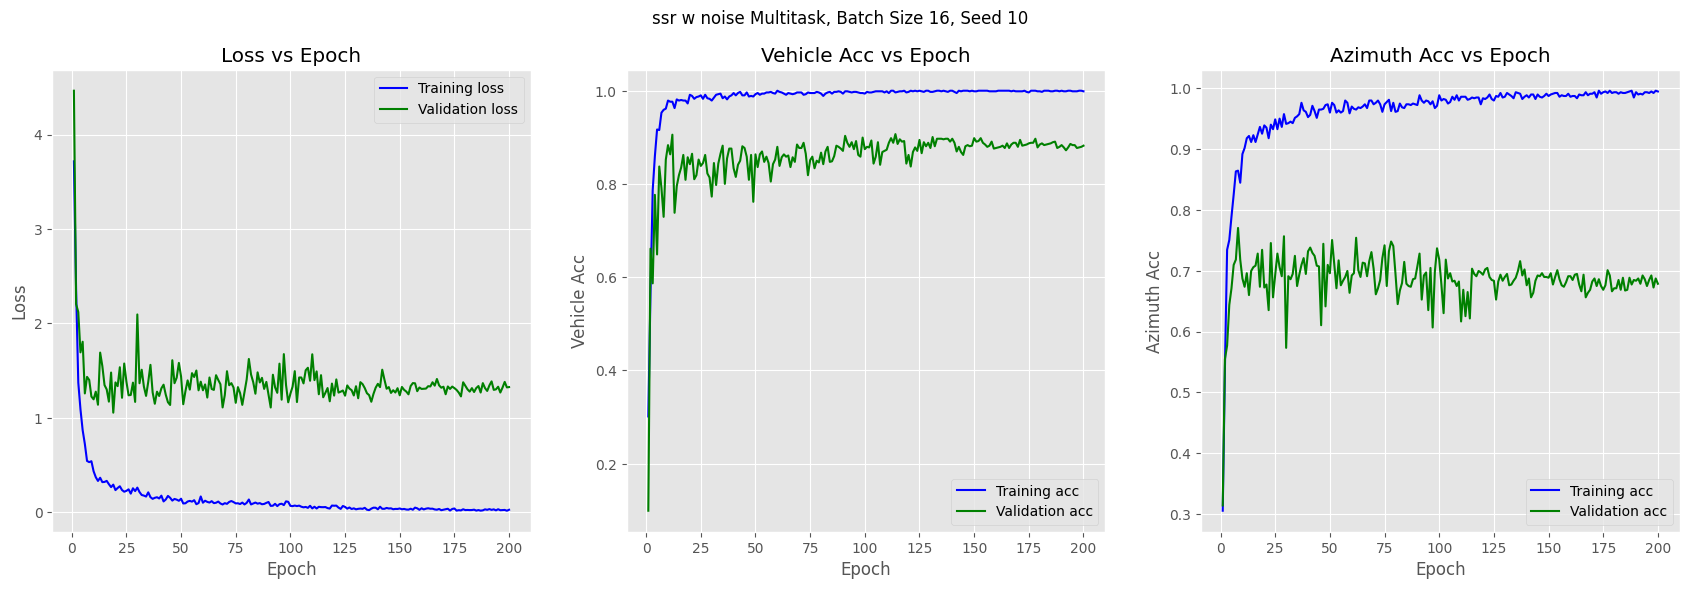

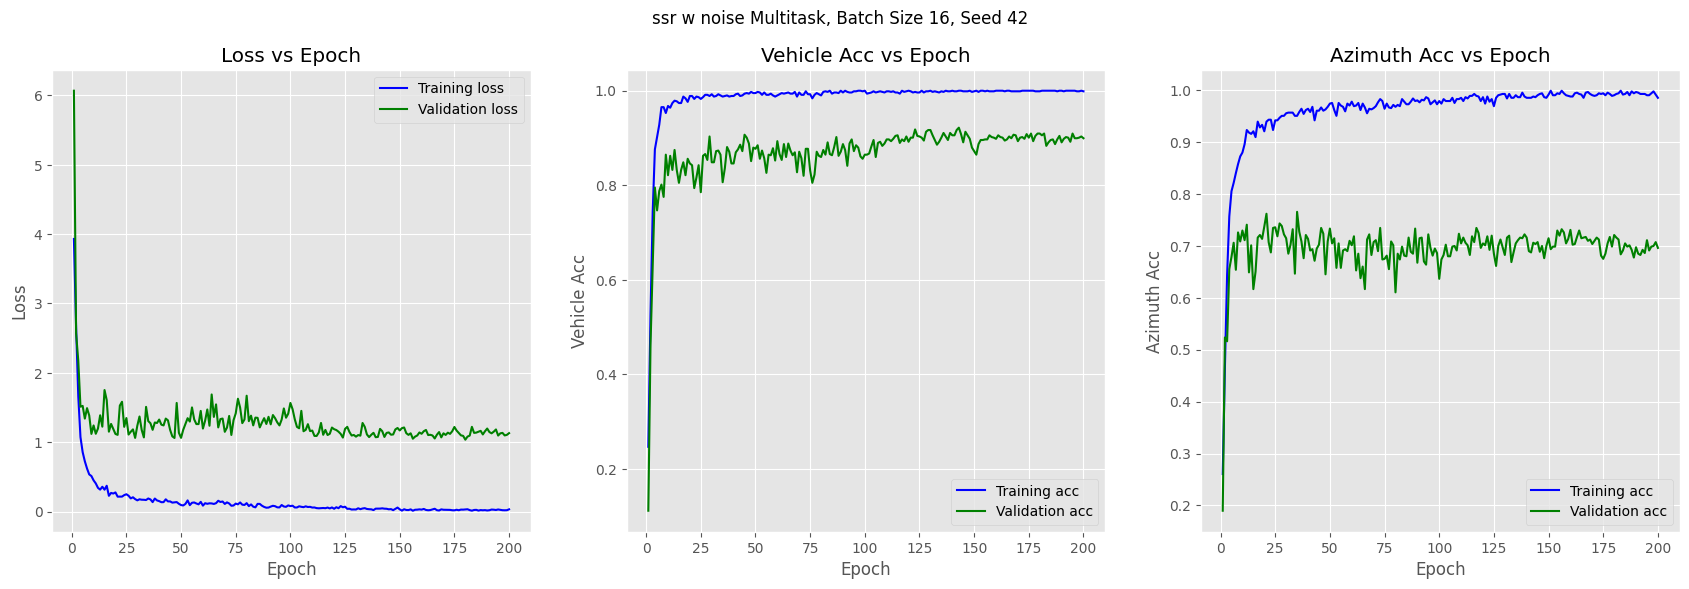

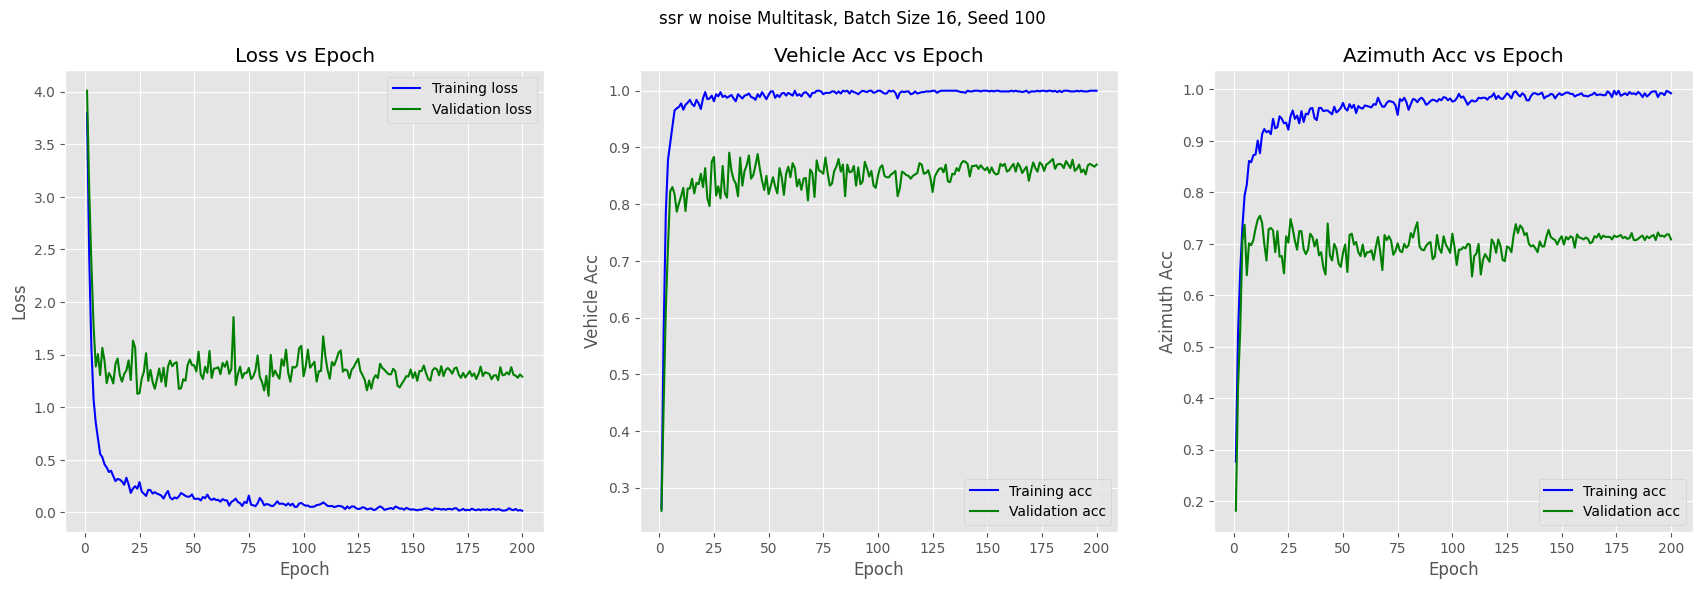

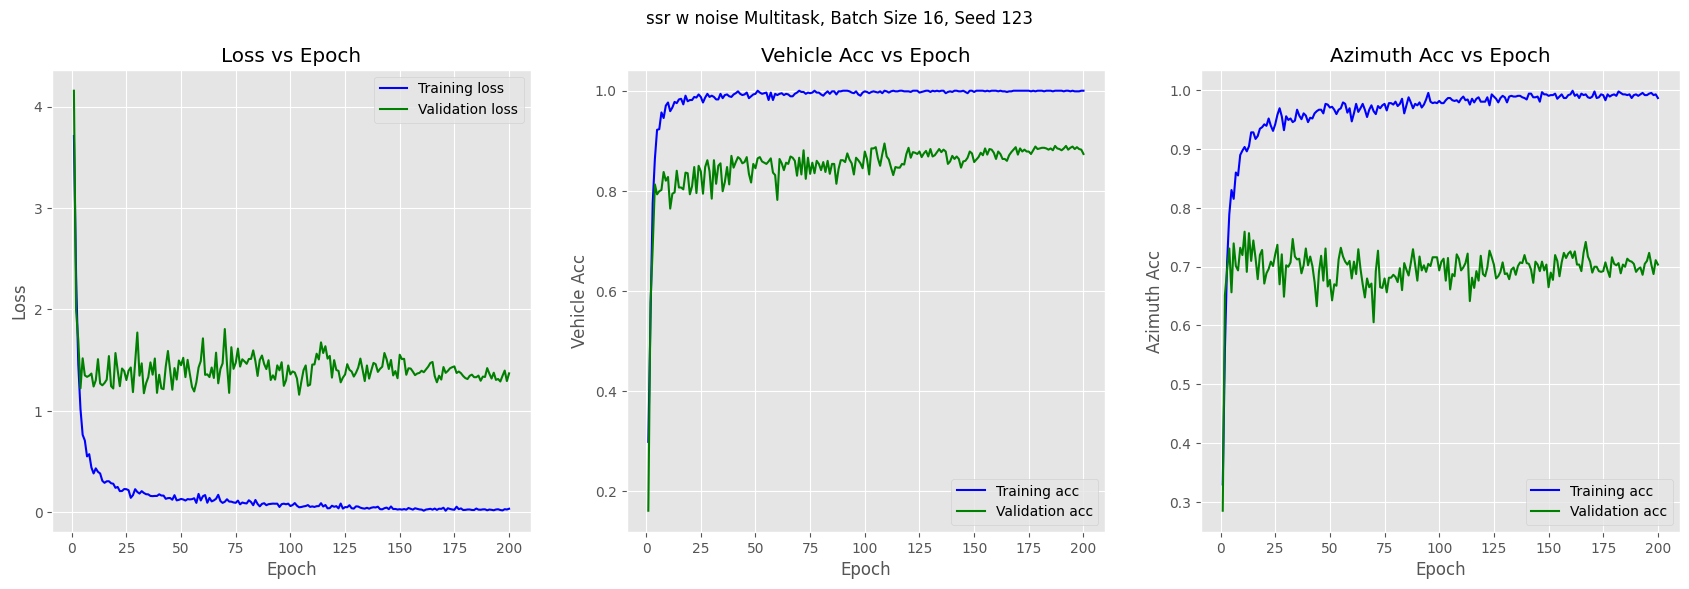

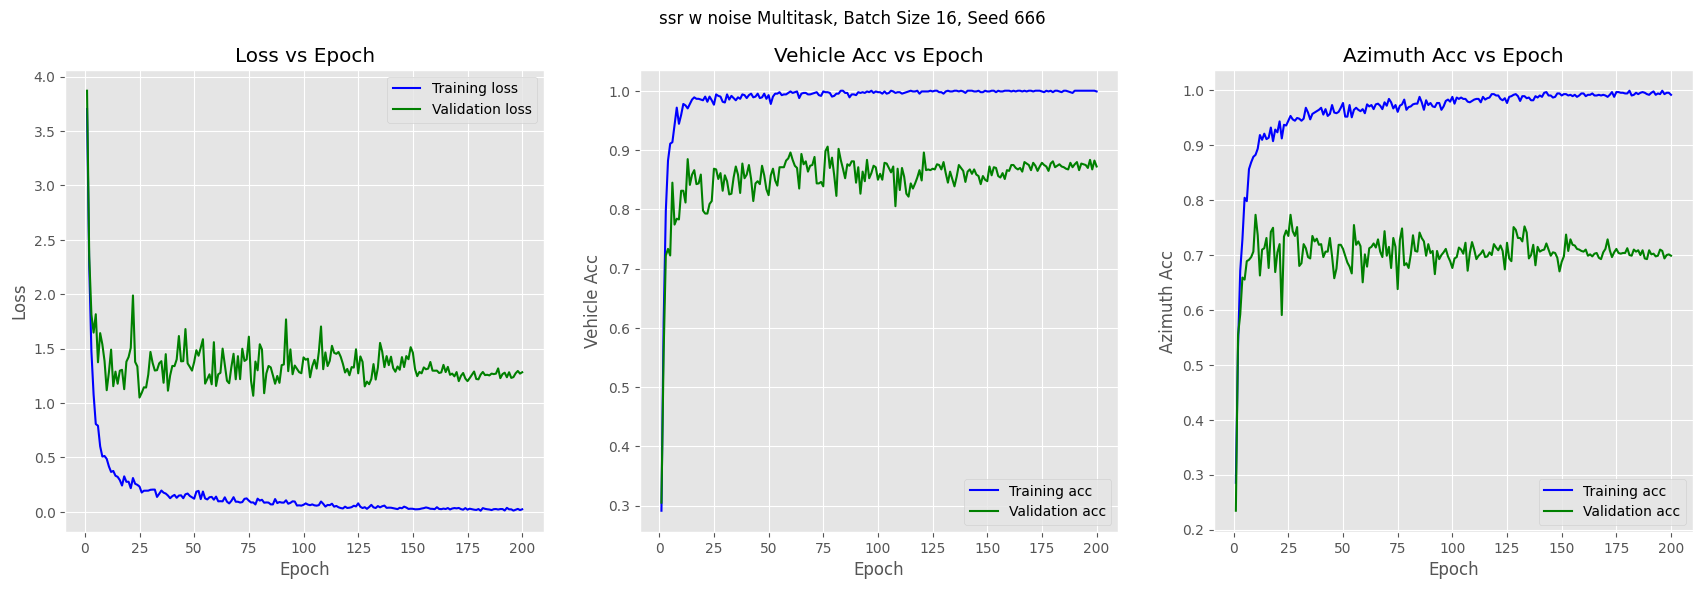

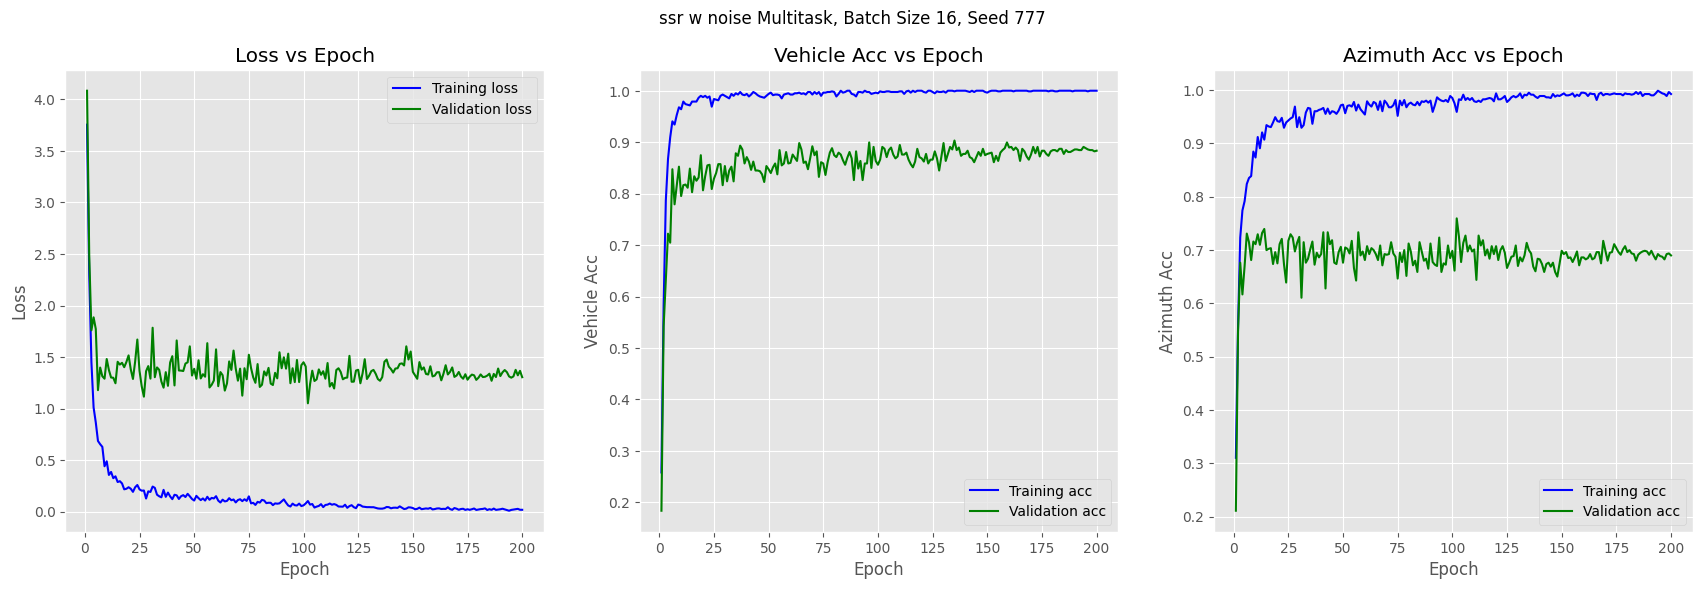

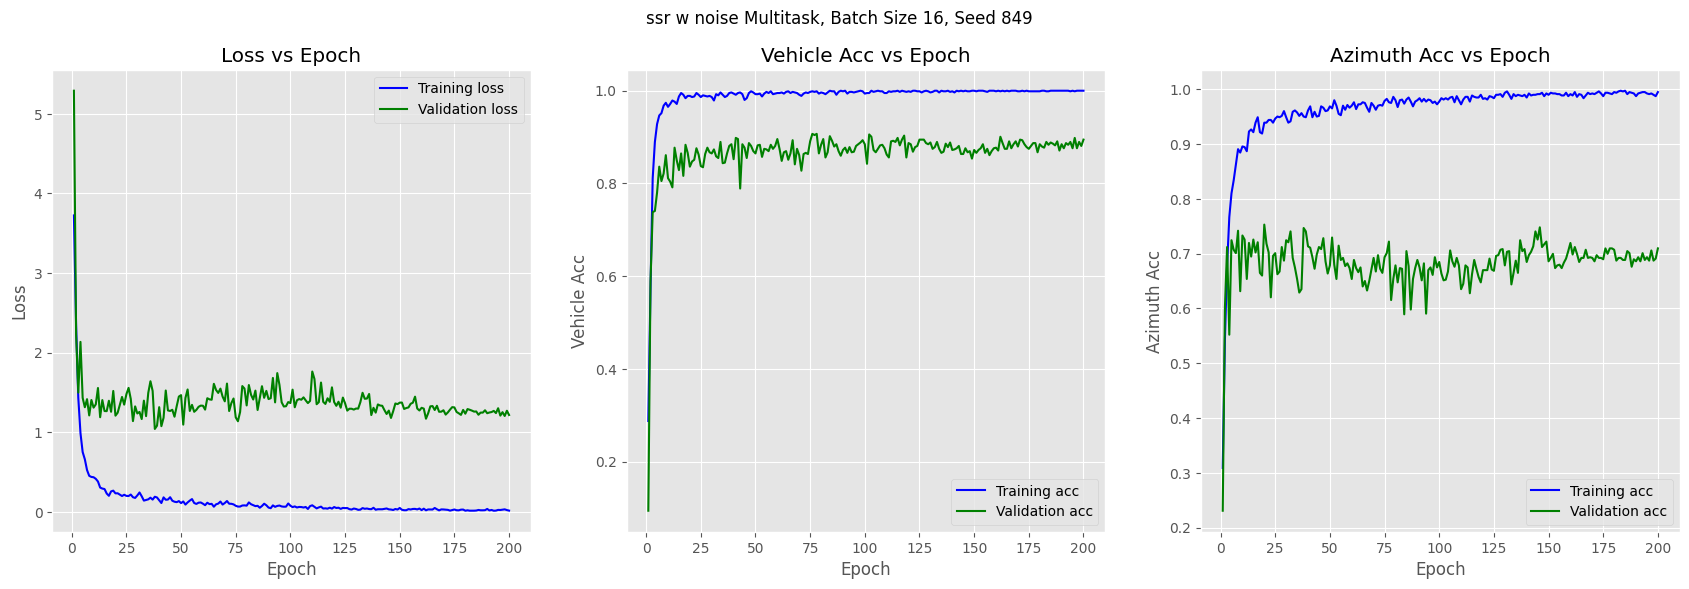

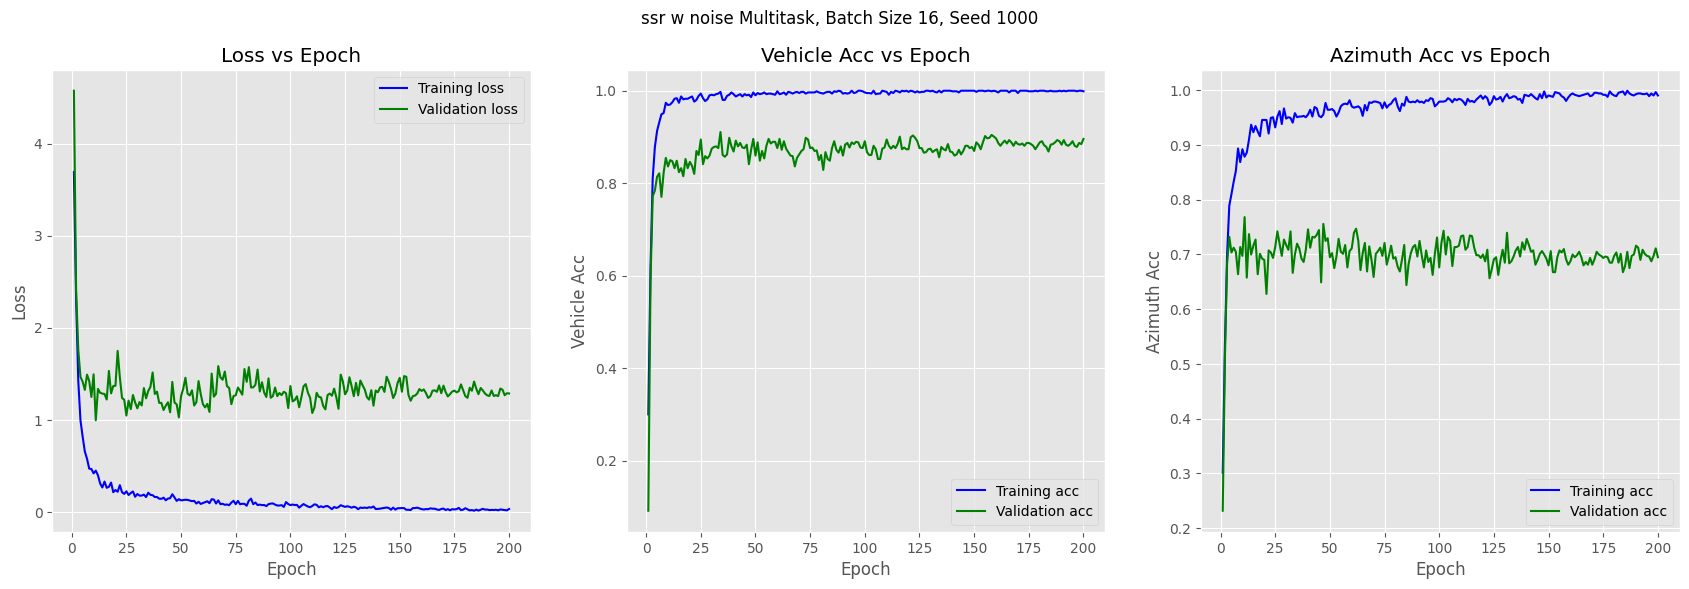

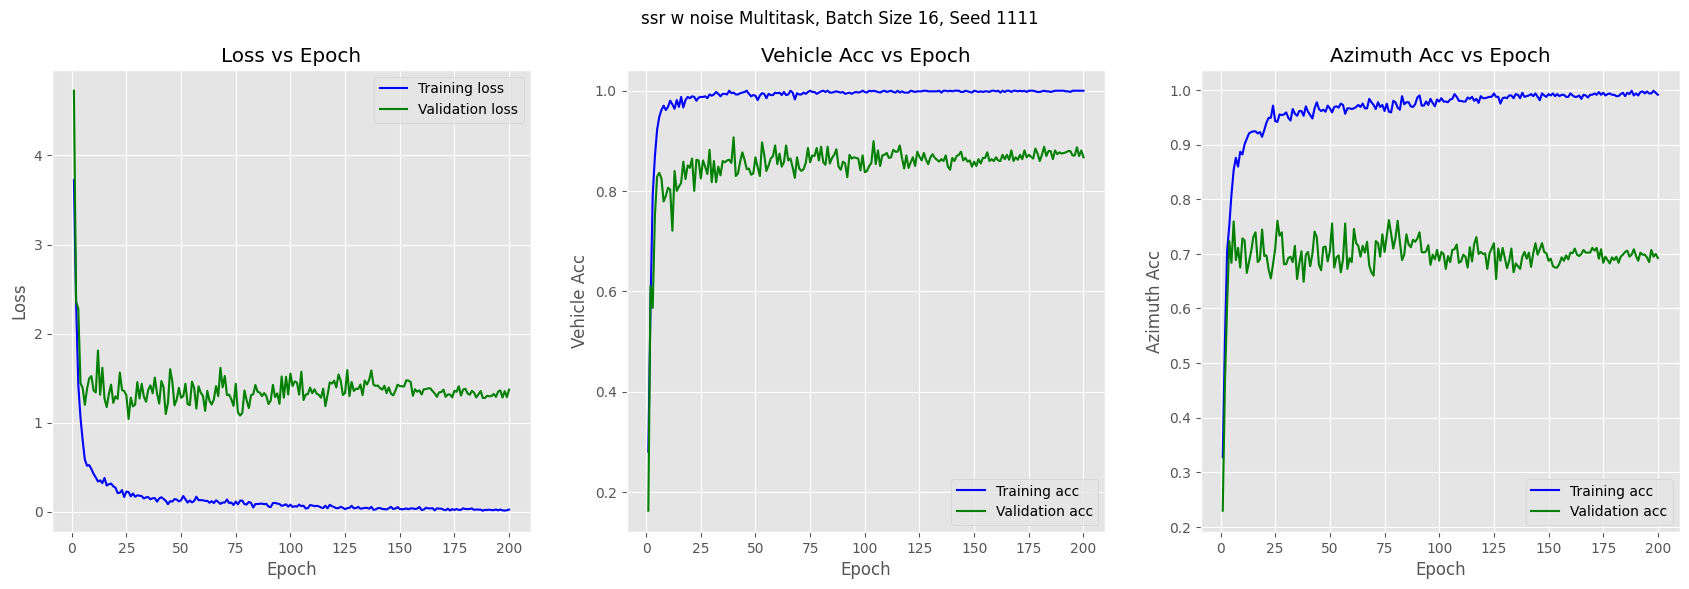

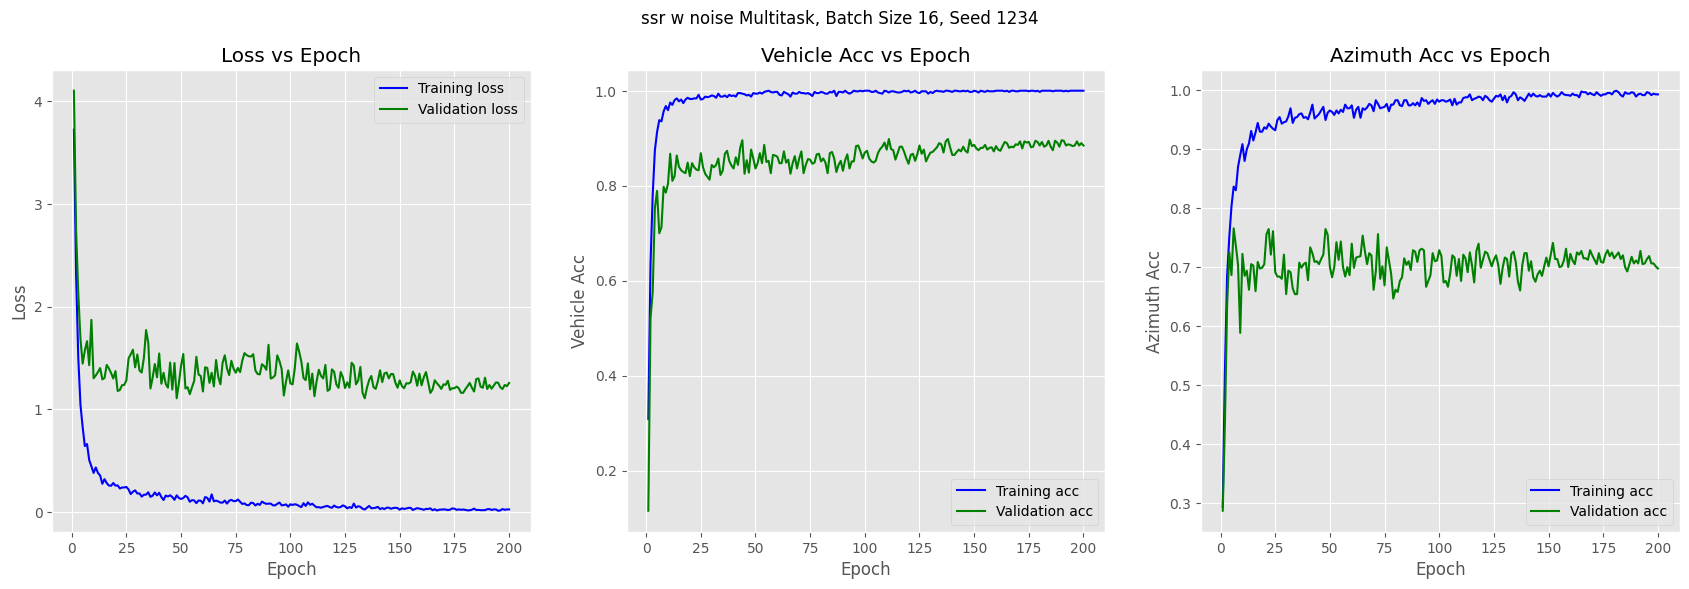

In [15]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (21, 6))
    
        ax0 = fig.add_subplot(1, 3, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 3, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_vehicle_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_vehicle_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Vehicle Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Vehicle Acc")
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(1, 3, 3)
        ax2.plot(np.arange(1, num_epochs+1), train_azimuth_acc[i, :], label = "Training acc", c = "blue")
        ax2.plot(np.arange(1, num_epochs+1), val_azimuth_acc[i, :], label = "Validation acc", c = "green")
        ax2.set_title("Azimuth Acc vs Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Azimuth Acc")
        ax2.legend()
        ax2.grid(True)
        
        fig.suptitle(f"ssr w noise Multitask, Batch Size 16, Seed {seed}")
        plt.show()

In [14]:
test_dataloader = DataLoader(multitask_test_ds, batch_size=32, shuffle=False, 
                            num_workers=8, pin_memory=True, persistent_workers=True, 
                            prefetch_factor=4)

seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    
    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    model = model.to(device)
    model.eval()

    n_test = dataset_sizes["test"]
    vehicle_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    vehicle_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    
    idx = 0
    with torch.no_grad():
        for inputs, vehicle_labels, azimuth_labels in test_dataloader:
            inputs = inputs.to(device)
            vehicle_labels = vehicle_labels.to(device)
            azimuth_labels = azimuth_labels.to(device)
    
            vehicle_logits, azimuth_logits = model(inputs)
            _, vehicle_preds = torch.max(vehicle_logits, 1)
            _, azimuth_preds = torch.max(azimuth_logits, 1)
    
            batch_size = vehicle_labels.size(0)
            vehicle_labels_tensor[idx : idx + batch_size] = vehicle_labels
            vehicle_preds_tensor[idx : idx + batch_size] = vehicle_preds
            azimuth_labels_tensor[idx : idx + batch_size] = azimuth_labels
            azimuth_preds_tensor[idx : idx + batch_size] = azimuth_preds
            idx += batch_size

    torch.cuda.synchronize()
    
    test_veh_acc = (vehicle_labels_tensor == vehicle_preds_tensor).float().mean()
    test_azimuth_acc = (azimuth_labels_tensor == azimuth_preds_tensor).float().mean()
    test_acc = ((vehicle_labels_tensor == vehicle_preds_tensor) & (azimuth_labels_tensor == azimuth_preds_tensor)).float().mean()
    print(f"Test Vehicle Accuracy: {test_veh_acc *100:.4f}\nTest Azimuth Accuracy: {test_azimuth_acc * 100:.4f}\nTest Joint Accuracy: {test_acc * 100:.4f}\n")
    test_acc_lst.append(test_acc.item())

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Vehicle Accuracy: 91.2802
Test Azimuth Accuracy: 69.2022
Test Joint Accuracy: 62.7087

Evaluating Run 1 with seed 42
Test Vehicle Accuracy: 93.3210
Test Azimuth Accuracy: 71.0575
Test Joint Accuracy: 66.2338

Evaluating Run 2 with seed 100
Test Vehicle Accuracy: 93.3210
Test Azimuth Accuracy: 70.8720
Test Joint Accuracy: 66.0482

Evaluating Run 3 with seed 123
Test Vehicle Accuracy: 88.8683
Test Azimuth Accuracy: 71.2430
Test Joint Accuracy: 63.4508

Evaluating Run 4 with seed 666
Test Vehicle Accuracy: 91.4657
Test Azimuth Accuracy: 71.0575
Test Joint Accuracy: 64.7495

Evaluating Run 5 with seed 777
Test Vehicle Accuracy: 91.4657
Test Azimuth Accuracy: 71.2430
Test Joint Accuracy: 64.1929

Evaluating Run 6 with seed 849
Test Vehicle Accuracy: 92.7644
Test Azimuth Accuracy: 70.8720
Test Joint Accuracy: 65.6772

Evaluating Run 7 with seed 1000
Test Vehicle Accuracy: 93.6920
Test Azimuth Accuracy: 72.9128
Test Joint Accuracy: 68.4601

Evaluating Run 8 